# Analisis de pregunta 2
### Pregunta de negocio:
¿Qué tan recurrente es la contratación de las mismas personas (mismo Documento Proveedor) a lo largo del tiempo, y qué tan comunes son las prórrogas?

Librerias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal

# Evita notación científica en las salidas de pandas.
pd.options.display.float_format = "{:,.2f}".format

Carga de datos

In [7]:
ARCHIVO_CSV = "datos_limpios.csv"
df = pd.read_csv(ARCHIVO_CSV)

Vista inicial

In [9]:
df.head()


,nombre_entidad,nit_entidad,codigo_entidad,departamento,ciudad,proceso_de_compra,id_contrato,estado_contrato,codigo_de_categoria_principal,descripcion_del_proceso,...,fecha_de_notificaci_n_de_prorrogaci_n,anio_firma,mes_firma,duracion_dias,duracion_inconsistente,unspsc,regional,es_prorrogable,tiene_notificacion_prorroga,es_contratacion_individual
0,SENA REGIONAL VALLE Grupo de Apoyo Administrat...,899999034,700763170,Valle del Cauca,Cali,CO1.BDOS.1674748,CO1.PCCNTR.2146739,terminado,V1.80111600,Prestar los servicios como Profesional Regiona...,...,NaN,"2,021.00",1.00,343.00,False,"80,111,600.00",Valle del Cauca,False,False,True
1,SENA REGIONAL VALLE Grupo de Apoyo Administrat...,899999034,700763170,Valle del Cauca,Cali,CO1.BDOS.2546395,CO1.PCCNTR.3280659,Cerrado,V1.80111600,Prestar los servicios profesionales para apoya...,...,NaN,"2,022.00",1.00,346.00,False,"80,111,600.00",Valle del Cauca,False,False,True
2,SENA REGIONAL ANTIOQUIA Grupo Administrativo CIAA,899999034,704160423,Antioquia,Rionegro,CO1.BDOS.1741951,CO1.PCCNTR.2229934,Cerrado,V1.80111600,5_9503_184 Prestar servicios personales de car...,...,2021-11-08,"2,021.00",2.00,313.00,False,"80,111,600.00",Antioquia,True,True,True
3,SENA Regional Huila Grupo de Apoyo Administrat...,899999034,702689464,Huila,Neiva,CO1.BDOS.9130377,CO1.PCCNTR.8650729,En ejecución,V1.90111503,41_9527_587 Contratar el servicio de operador ...,...,2025-12-08,"2,025.00",11.00,14.00,False,"90,111,503.00",Huila,True,True,True
4,SENA REGIONAL TOLIMA 1,899999034,702561986,Tolima,Ibagué,CO1.BDOS.1729110,CO1.PCCNTR.2228398,Modificado,V1.80111600,Prestación de servicios de apoyo a la gestión ...,...,NaN,"2,021.00",2.00,309.00,False,"80,111,600.00",Tolima,True,False,True


Dimensiones


In [10]:
df.shape


(328057, 35)

### Recurrencia de proveedores 

Números de contratos por proveedor 

In [11]:
# Contar cuántos contratos tiene cada proveedor
contratos_por_proveedor = (
    df.groupby("documento_proveedor")["id_contrato"]
      .nunique()
      .reset_index(name="numero_contratos")
)

contratos_por_proveedor.head()

,documento_proveedor,numero_contratos
0,00,1
1,000000,3
2,0000000,7
3,00000000,14
4,0000000000,4


Recurrencia de proveedor

In [12]:
distribucion_recurrencia = (
    contratos_por_proveedor["numero_contratos"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_recurrencia.columns = ["numero_contratos", "numero_proveedores"]

distribucion_recurrencia

,numero_contratos,numero_proveedores
0,1,28057
1,2,15924
2,3,10708
3,4,7434
4,5,5504
...,...,...
105,184,1
106,225,1
107,229,1
108,426,1


Porcentaje de proveedores recurrentes

In [13]:
total_proveedores = len(contratos_por_proveedor)

proveedores_recurrentes = (
    contratos_por_proveedor["numero_contratos"] >= 2
).sum()

porcentaje_recurrentes = (
    proveedores_recurrentes / total_proveedores * 100
)

print(f"Total de proveedores: {total_proveedores:,}")
print(f"Proveedores recurrentes: {proveedores_recurrentes:,}")
print(f"Porcentaje de proveedores recurrentes: {porcentaje_recurrentes:.2f}%")

Total de proveedores: 88,724
Proveedores recurrentes: 60,667
Porcentaje de proveedores recurrentes: 68.38%


Promedio de contratos por proveedor

In [15]:
promedio_contratos = contratos_por_proveedor["numero_contratos"].mean()

print(f"Promedio de contratos por proveedor: {promedio_contratos:.2f}")

Promedio de contratos por proveedor: 3.70


Distribución de proveedores 

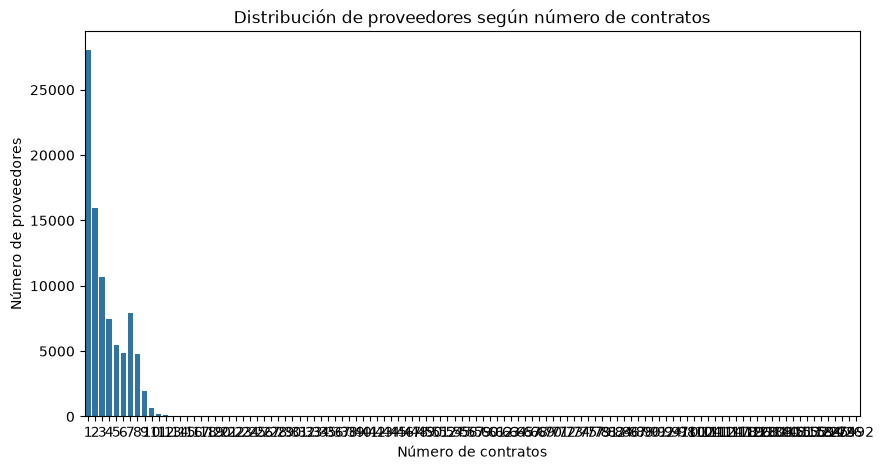

In [14]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=distribucion_recurrencia,
    x="numero_contratos",
    y="numero_proveedores"
)

plt.title("Distribución de proveedores según número de contratos")
plt.xlabel("Número de contratos")
plt.ylabel("Número de proveedores")
plt.show()

### Recurrencia a traves del tiempo

En cuantos años ha sido contratado cada proveedor

In [17]:
# Convertir la fecha de firma a formato fecha
df["fecha_de_firma"] = pd.to_datetime(df["fecha_de_firma"], errors="coerce")

# Extraer el año
df["año"] = df["fecha_de_firma"].dt.year

años_por_proveedor = (
    df.groupby("documento_proveedor")["año"]
      .nunique()
      .reset_index(name="numero_años")
)

años_por_proveedor.head()

,documento_proveedor,numero_años
0,00,1
1,000000,0
2,0000000,0
3,00000000,1
4,0000000000,2


Cuantos proveedores fuero contratatados en mas de dos años diferentes

In [18]:
total_proveedores = len(años_por_proveedor)

proveedores_varios_años = (
    años_por_proveedor["numero_años"] >= 2
).sum()

porcentaje_varios_años = (
    proveedores_varios_años / total_proveedores * 100
)

print(f"Total de proveedores: {total_proveedores:,}")
print(f"Proveedores contratados en 2 o más años: {proveedores_varios_años:,}")
print(f"Porcentaje: {porcentaje_varios_años:.2f}%")

Total de proveedores: 88,724
Proveedores contratados en 2 o más años: 58,195
Porcentaje: 65.59%


Distribución de proveedores según años contratados

In [19]:
distribucion_años = (
    años_por_proveedor["numero_años"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_años.columns = ["numero_años", "numero_proveedores"]

distribucion_años

,numero_años,numero_proveedores
0,0,1050
1,1,29479
2,2,16577
3,3,11074
4,4,7693
5,5,5495
6,6,4992
7,7,11727
8,8,625
9,9,10


Promedio de años en los que cada proveedor fue contratado

In [21]:
promedio_años = años_por_proveedor["numero_años"].mean()

print(f"Promedio de años contratados por proveedor: {promedio_años:.2f}")

Promedio de años contratados por proveedor: 3.06


Proveedores según número de años con contratos

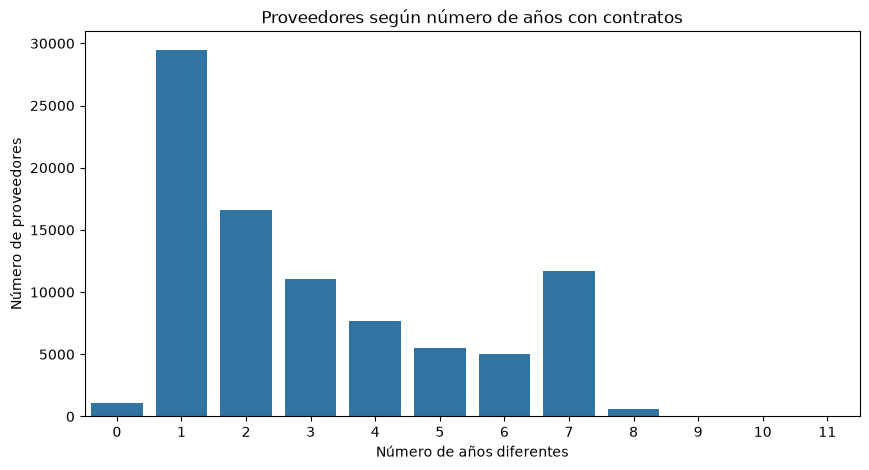

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=distribucion_años,
    x="numero_años",
    y="numero_proveedores"
)

plt.title("Proveedores según número de años con contratos")
plt.xlabel("Número de años diferentes")
plt.ylabel("Número de proveedores")
plt.show()

### Frecuencia de las prorrogas

Cálculo de la frecuenca de las prorogas

In [ ]:
# Crear indicador de prórroga
df["tuvo_prorroga"] = df["dias_adicionados"].fillna(0) > 0

# Verificar resultados
df["tuvo_prorroga"].value_counts()

tuvo_prorroga
False    299587
True      28470
Name: count, dtype: int64

In [23]:
total_contratos = df["id_contrato"].nunique()

contratos_prorrogados = df.loc[
    df["tuvo_prorroga"], "id_contrato"
].nunique()

porcentaje_prorrogados = (
    contratos_prorrogados / total_contratos * 100
)

print(f"Total de contratos: {total_contratos:,}")
print(f"Contratos prorrogados: {contratos_prorrogados:,}")
print(f"Porcentaje de contratos prorrogados: {porcentaje_prorrogados:.2f}%")

Total de contratos: 328,057
Contratos prorrogados: 28,470
Porcentaje de contratos prorrogados: 8.68%


Contratos prorrogados vs no prorrogados

In [ ]:
frecuencia_prorrogas = pd.DataFrame({
    "tipo": ["Sin prórroga", "Con prórroga"],
    "numero_contratos": [
        total_contratos - contratos_prorrogados,
        contratos_prorrogados
    ]
})

frecuencia_prorrogas

,tipo,numero_contratos
0,Sin prórroga,299587
1,Con prórroga,28470


Grafico de contratos prorrogados y no prorrogados

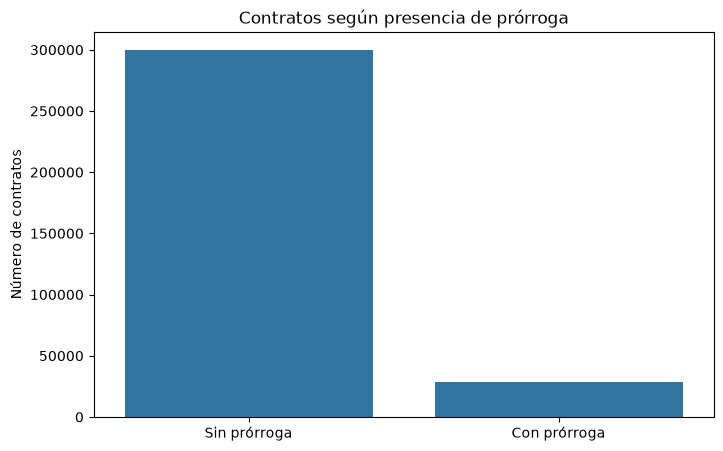

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=frecuencia_prorrogas,
    x="tipo",
    y="numero_contratos"
)

plt.title("Contratos prorrogados y no prorrogados")
plt.xlabel("")
plt.ylabel("Número de contratos")
plt.show()

Estadisticas de dias prorrogados 

In [26]:
dias_prorroga = df.loc[
    df["tuvo_prorroga"], "dias_adicionados"
]

print(f"Promedio de días adicionados: {dias_prorroga.mean():.2f}")
print(f"Mediana de días adicionados: {dias_prorroga.median():.2f}")
print(f"Mínimo de días adicionados: {dias_prorroga.min():.0f}")
print(f"Máximo de días adicionados: {dias_prorroga.max():.0f}")

Promedio de días adicionados: 35.46
Mediana de días adicionados: 17.00
Mínimo de días adicionados: 1
Máximo de días adicionados: 1833


Distribución de los días adicionados

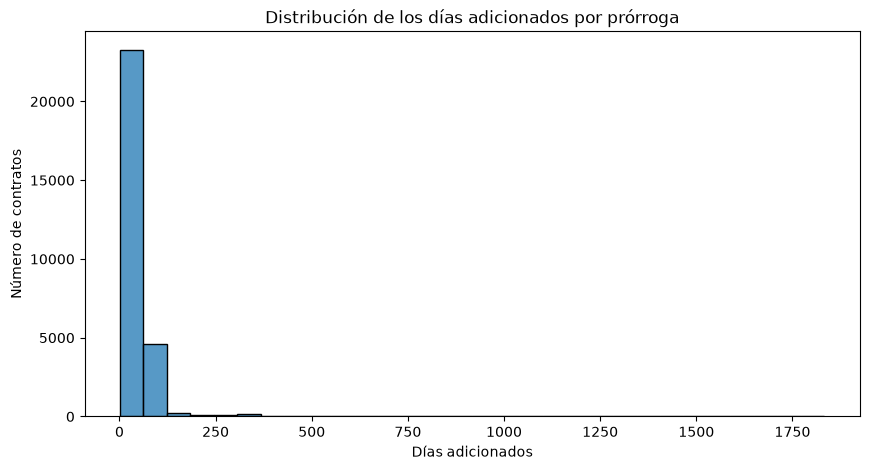

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(
    dias_prorroga,
    bins=30
)

plt.title("Distribución de los días adicionados por prórroga")
plt.xlabel("Días adicionados")
plt.ylabel("Número de contratos")
plt.show()